<a href="https://colab.research.google.com/github/LocoBunny04/ACMP2000-Data-ML/blob/main/Kawinthida_Haase_Network_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# First steps: loading and visualizing a small network

We will use the `networkx` library, an industry standard for network analysis, and matplotlib for visualization.

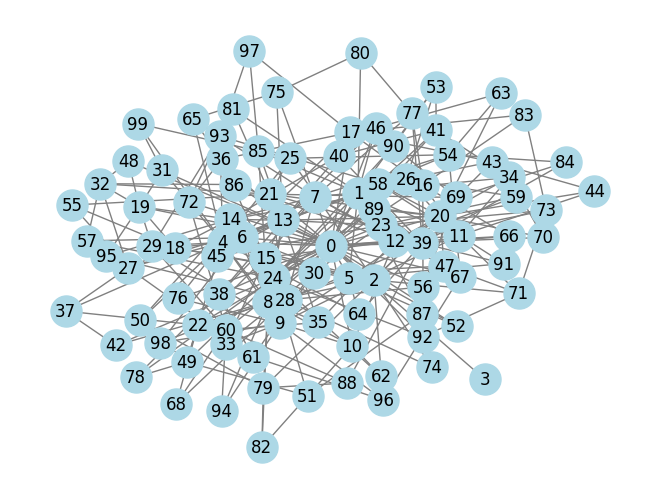

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import random

# Scale-free network
scale_free_G = nx.barabasi_albert_graph(100, 3, seed=1)
# Drawing graph
pos = nx.spring_layout(scale_free_G, seed=1)
nx.draw(scale_free_G, pos, with_labels=True, node_color='lightblue',
        node_size=500, edge_color='gray')


Graph with 100 nodes and 508 edges


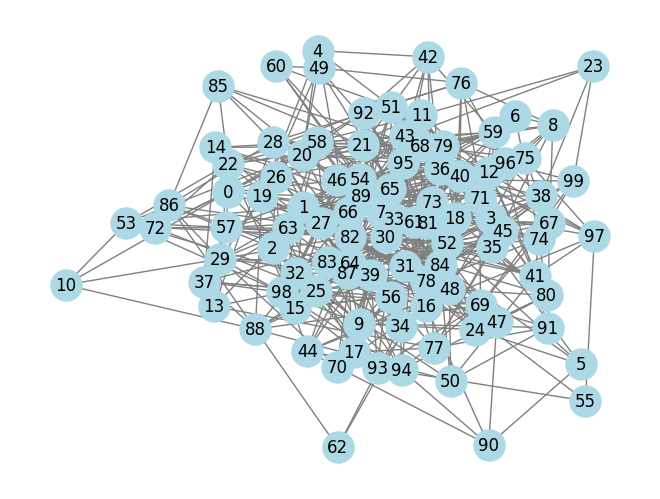

In [3]:
# Random Graph

# Adding Random Graph
n = 100 # number of nodes
p = 0.1 # probability of an edge between pairs of nodes
random_G = nx.erdos_renyi_graph(n, p, seed=1)

pos = nx.spring_layout(random_G, seed=1)
nx.draw(random_G, pos, with_labels=True, node_color='lightblue', node_size=500,
        edge_color='gray')
print(random_G)

# Simulating Attack

291


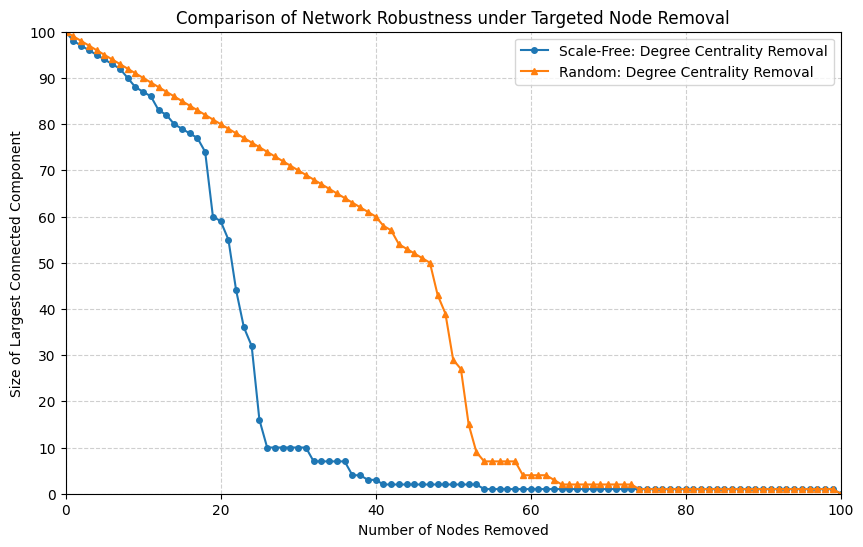

In [4]:
import random
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# create a Barabási-Albert scale-free graph
scale_free_G = nx.barabasi_albert_graph(100, 3, seed=1)
scale_free_G_copy = scale_free_G.copy()

print(scale_free_G.number_of_edges())

# create a random graph
random_G = nx.erdos_renyi_graph(100, 0.1, seed=1)
# Make a separate copy to safely modify during node removal
random_G_copy = random_G.copy()


# get the initial size of the largest connected component
initial_lcc_size_sf = len(max(nx.connected_components(scale_free_G_copy), key=len))
initial_lcc_size_rand = len(max(nx.connected_components(random_G_copy), key=len))

# prepare lists to store LCC sizes
lcc_sizes_sf_degree = [initial_lcc_size_sf]
lcc_sizes_rand_degree = [initial_lcc_size_rand]


# initialize counters for tracking node removal
i = 0

num_nodes_sf = len(scale_free_G_copy)
num_nodes_rand = len(random_G_copy)

# remove nodes in parallel from both networks using high-degree node removal
while i < max(num_nodes_sf, num_nodes_rand):

    # sort nodes by degree in descending order for scale-free graph
    if len(scale_free_G_copy) > 0:
        nodes_sorted_by_degree_sf = sorted(scale_free_G_copy.degree, key=lambda x: x[1],
                                           reverse=True)
        # high-degree node removal from scale_free_G
        node_to_remove_sf = nodes_sorted_by_degree_sf[0][0]
        scale_free_G_copy.remove_node(node_to_remove_sf)
        # check largest connected component size after removal
        if len(scale_free_G_copy) > 0:
          largest_cc_sf_degree = max(nx.connected_components(scale_free_G_copy), key=len)
          lcc_sizes_sf_degree.append(len(largest_cc_sf_degree))
        else:
            lcc_sizes_sf_degree.append(0) # Append 0 if graph is empty

    # sort nodes by degree in descending order for random graph

    if len(random_G_copy) > 0:
         nodes_sorted_by_degree_rand = sorted(random_G_copy.degree, key=lambda x: x[1],
                                           reverse=True)
         # high-degree node removal from random_G
         node_to_remove_rand = nodes_sorted_by_degree_rand[0][0]
         random_G_copy.remove_node(node_to_remove_rand)
         # check largest connected component size after removal
         if len(random_G_copy) > 0:
             largest_cc_rand_degree = max(nx.connected_components(random_G_copy), key=len)
             lcc_sizes_rand_degree.append(len(largest_cc_rand_degree))
         else:
            lcc_sizes_rand_degree.append(0) # Append 0 if graph is empty

    i += 1

# plot the results
plt.figure(figsize=(10, 6))
plt.plot(range(len(lcc_sizes_sf_degree)), lcc_sizes_sf_degree,
         label='Scale-Free: Degree Centrality Removal', marker='o', linestyle='-', markersize=4)
plt.plot(range(len(lcc_sizes_rand_degree)), lcc_sizes_rand_degree,
         label='Random: Degree Centrality Removal', marker='^', linestyle='-', markersize=4)

plt.title("Comparison of Network Robustness under Targeted Node Removal")
plt.xlabel("Number of Nodes Removed")
plt.ylabel("Size of Largest Connected Component")

# Zooming in to see the difference better
plt.ylim(0, 100)          # focuses on 0–100 normalized range
plt.xlim(0, 100)        # optional, ensures full width shown
plt.yticks(np.arange(0, 101, 10))  # adds clearer y tick marks
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Analysis

The results show that in the **Scale-free graph**, the size of the largest connected component (LCC) decreases rapidly as more high-degree nodes are removed. This is the result since the small number of nodes hold the network together with its many connection removing these hubs quickly breaks the network into smaller disconnected parts.

However, you can see that the orange line for **random graph maintains** the LCC longer. This is attributed to the fact that random networks do not rely on any singular node to maintain its connectivity; and their links are spread more evenly. As a result, removing even the most connected nodes has a smaller impact on overall connectivity.

The simulation shows that scale-free graphs, are more vulnerable to attack that remove hub nodes. While networks that has connections more evenly spread out (random networks) are better able to withstand such targeted attacks. Despite this, scale-free are better for its robustness against random failures where nodes are removed without targeting.

# Grade:
36/40 pts. #36/40 pts : All correct, except that the probability for the random graph is too high and will not generate a comparable number of edges, as you can verify by printing the number of edges of the random graph.
p ~ 0.0541 does the job